In [1]:
# Mount Drive and load 70/10/20 models
from google.colab import drive
drive.mount('/content/drive')

import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pickle
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

STGCN_DIR  = '/content/st-gcn'
CTRGCN_DIR = '/content/CTR-GCN'

# Clone ST-GCN
if not os.path.exists(STGCN_DIR):
    os.system(f'git clone https://github.com/yysijie/st-gcn.git {STGCN_DIR}')
stgcn_io = Path(f'{STGCN_DIR}/torchlight/torchlight/io.py')
text = stgcn_io.read_text()
if 'weights_only=False' not in text:
    text = text.replace('torch.load(weights_path)', 'torch.load(weights_path, weights_only=False, map_location="cpu")')
    stgcn_io.write_text(text)
os.system(f'pip install -e {STGCN_DIR}/torchlight -q')

# Clone CTR-GCN
if not os.path.exists(CTRGCN_DIR):
    os.system(f'git clone https://github.com/Uason-Chen/CTR-GCN.git {CTRGCN_DIR}')
os.system('pip install -q tensorboardX torchpack fvcore iopath yacs thop')
os.system(f'pip install -e {CTRGCN_DIR}/torchlight -q')
ctrgcn_util = Path(f'{CTRGCN_DIR}/torchlight/torchlight/util.py')
text = ctrgcn_util.read_text()
if 'PaviLogger = None' not in text:
    text = text.replace('from torchpack.runner.hooks import PaviLogger', 'try:\n    from torchpack.runner.hooks import PaviLogger\nexcept ImportError:\n    PaviLogger = None')
    ctrgcn_util.write_text(text)

print("Loading model architectures...")

# Load ST-GCN
sys.path.insert(0, STGCN_DIR)
from net.st_gcn import Model as STGCN_Model
stgcn_model = STGCN_Model(in_channels=3, num_class=30, dropout=0.5, edge_importance_weighting=True, graph_args={'layout': 'ntu-rgb+d', 'strategy': 'spatial'})
stgcn_ckpt = torch.load('/content/drive/MyDrive/HRC_Research/checkpoints/stgcn_hri30_70_10_20/best_stgcn_hri30.pt', map_location='cpu', weights_only=False)
stgcn_state = stgcn_ckpt['model_state_dict'] if isinstance(stgcn_ckpt, dict) and 'model_state_dict' in stgcn_ckpt else stgcn_ckpt
stgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in stgcn_state.items()}
stgcn_model.load_state_dict(stgcn_state, strict=True)
stgcn_model = stgcn_model.to(device)
stgcn_model.eval()
print("ST-GCN loaded ✓")

# Load CTR-GCN
sys.path.insert(0, CTRGCN_DIR)
from model.ctrgcn import Model as CTRGCN_Model
ctrgcn_model = CTRGCN_Model(num_class=30, num_point=25, num_person=1, graph='graph.ntu_rgb_d.Graph', graph_args={'labeling_mode': 'spatial'})
ctrgcn_ckpt = torch.load('/content/drive/MyDrive/HRC_Research/checkpoints/ctrgcn_hri30_70_10_20/best_ctrgcn_hri30.pt', map_location='cpu', weights_only=False)
ctrgcn_state = ctrgcn_ckpt['model_state_dict'] if isinstance(ctrgcn_ckpt, dict) and 'model_state_dict' in ctrgcn_ckpt else ctrgcn_ckpt
ctrgcn_state = {k[7:] if k.startswith('module.') else k: v for k, v in ctrgcn_state.items()}
ctrgcn_model.load_state_dict(ctrgcn_state, strict=True)
ctrgcn_model = ctrgcn_model.to(device)
ctrgcn_model.eval()
print("CTR-GCN loaded ✓")

Mounted at /content/drive
Using device: cuda
Loading model architectures...
ST-GCN loaded ✓
CTR-GCN loaded ✓


In [2]:
# Run consensus on the 294 validation samples and calculate tau
def get_model_logits(model, data_np, batch_size=64):
    model.eval()
    all_logits = []
    N = data_np.shape[0]
    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            batch = torch.tensor(data_np[start:end], dtype=torch.float32).to(device)
            output = model(batch)
            all_logits.append(output.cpu().numpy())
    return np.concatenate(all_logits)

def softmax(logits):
    exp_x = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-9), axis=1)

# Load Val Data
STGCN_VAL_DATA = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/val_data.npy'
STGCN_VAL_LABEL = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/stgcn_format/val_label.pkl'
CTRGCN_VAL_NPZ = '/content/drive/MyDrive/HRC_Research/datasets/HRI30/HRI30_70_10_20/ctrgcn_format/HRI30_CS.npz'

stgcn_val_data = np.load(STGCN_VAL_DATA)
with open(STGCN_VAL_LABEL, 'rb') as f:
    _, y_val = pickle.load(f)
val_labels = np.array(y_val)

npz_val = np.load(CTRGCN_VAL_NPZ)
ctrgcn_val_data = npz_val['x_val']

# Run inference
logits_st_val = get_model_logits(stgcn_model, stgcn_val_data)
logits_ctr_val = get_model_logits(ctrgcn_model, ctrgcn_val_data)

# Consensus Fusion
probs_st_val = softmax(logits_st_val)
probs_ctr_val = softmax(logits_ctr_val)
H_st_val = entropy(probs_st_val)
H_ctr_val = entropy(probs_ctr_val)
W_st_val = np.exp(-H_st_val)
W_ctr_val = np.exp(-H_ctr_val)
norm_val = W_st_val + W_ctr_val
W_st_val /= norm_val
W_ctr_val /= norm_val
probs_fused_val = W_st_val[:, None] * probs_st_val + W_ctr_val[:, None] * probs_ctr_val

# Extract confidence and correctness
conf_val = np.max(probs_fused_val, axis=1)
preds_val = np.argmax(probs_fused_val, axis=1)
correct_val = (preds_val == val_labels).astype(int)

# Calculate Tau using Youden's J on ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(correct_val, conf_val)
youden_j = tpr - fpr
tau_new = float(thresholds[np.argmax(youden_j)])

print(f"Val set consensus accuracy: {correct_val.mean()*100:.2f}%")
print(f"New tau (val-only, n=294): {tau_new:.4f}")

Val set consensus accuracy: 70.41%
New tau (val-only, n=294): 0.7080


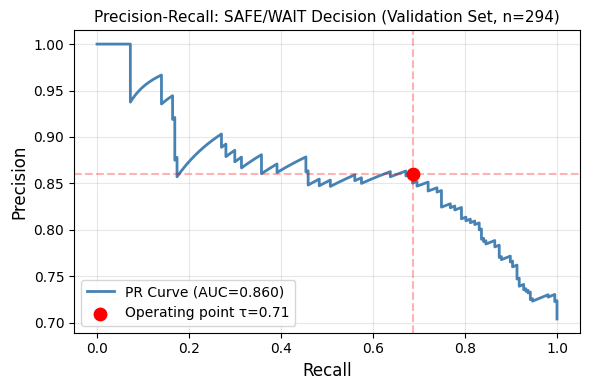

Saved → /content/drive/MyDrive/HRC_Research/figures/pr_curve_tau_70_10_20.pdf
Operating point: Recall=0.686 Precision=0.861


In [3]:
# Generate and save PR Curve
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import os

precision_arr, recall_arr, pr_thresh = precision_recall_curve(correct_val, conf_val)
pr_auc = auc(recall_arr, precision_arr)

# Find the point on the curve closest to tau_new
closest_idx = np.argmin(np.abs(pr_thresh - tau_new))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_arr, precision_arr, label=f"PR Curve (AUC={pr_auc:.3f})", color="steelblue", linewidth=2)
ax.scatter(recall_arr[closest_idx], precision_arr[closest_idx], color="red", zorder=5, s=80, label=f"Operating point τ={tau_new:.2f}")
ax.axvline(x=recall_arr[closest_idx], color="red", linestyle="--", alpha=0.3)
ax.axhline(y=precision_arr[closest_idx], color="red", linestyle="--", alpha=0.3)

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall: SAFE/WAIT Decision (Validation Set, n=294)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

FIG_DIR = '/content/drive/MyDrive/HRC_Research/figures'
os.makedirs(FIG_DIR, exist_ok=True)
fig_path = os.path.join(FIG_DIR, 'pr_curve_tau_70_10_20.pdf')
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved → {fig_path}")
print(f"Operating point: Recall={recall_arr[closest_idx]:.3f} Precision={precision_arr[closest_idx]:.3f}")